<a href="https://colab.research.google.com/github/lynnv-hub/Mind_Reading/blob/main/MindReading_Report1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 90.8 MB/s eta 0:00:00


# Structural Imaging Assignment
For this assignment, you will work with MRI data from approximately 900 participants from the Amsterdam Open MRI Collection (AOMIC). The dataset is described in detail here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. Sci Data 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

FreeSurfer preprocessing has already been completed. You will receive:

- A CSV table with FreeSurfer-derived measures (cortical thickness, surface area, curvature, subcortical volumes)
- A table with demographic information (age, biological sex)
- A data dictionary explaining each column

### Your Task
Build a classification model to predict biological sex from brain structure. Specifically:
- Identify which brain measures contribute most to classification
- Quantify effect sizes and classification performance
- Characterise the degree of overlap between groups
- Discuss what your findings reveal about sex differences in brain structure

For this assignment, you will use logistic regression to classify sex from brain structure. Logistic regression is appropriate for binary classification, computationally efficient, and provides interpretable coefficients indicating which features contribute most to classification.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas. You can also refer to the notebooks from the lab practicals, especially Lab 4 on predicting age from brain structure.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [3]:
# ------- Leave this code as is -----------
### Loading the data

import os
import pandas as pd
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Download required data files
for url, name in zip([
        "https://www.dropbox.com/scl/fi/kssezv0bic0asdlug4vtn/demographic_data.csv?rlkey=rn3zs0ggjcprkcmec54uy6s5s&dl=1",
        "https://www.dropbox.com/scl/fi/ypa33lzz0mlx8cswz9nej/morphology_data.csv?rlkey=awl906mvp10pofv6hjilfzl8e&dl=1"
    ],
    [
        "demographic_data.csv",
        "morphology_data.csv"
    ]):

    download_file(url, name)

demography_df = pd.read_csv("demographic_data.csv")
morphology_df = pd.read_csv("morphology_data.csv")

Saved as demographic_data.csv
Saved as morphology_data.csv


### Part 1: Code Implementation (30%)
Implement your proposed analysis with clear structure

Include comments or markdown cells explaining:
- What each code section does
- Why you made specific methodological choices (e.g., "Using 5-fold CV to balance bias-variance tradeoff")
- Any assumptions or decisions about data handling
- Ensure code runs without errors

You can use the code below as a starting point.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from matplotlib.patches import Patch

# Merging both files to ensure that the data is aligned correctly
data_df = pd.merge(demography_df, morphology_df, on="participant_id")
print(f"Full dataset shape: {data_df.shape}")
print(data_df['sex'].value_counts())

# Feature selection: cortical thickness + subcortical volumes
# Excluded: surface area curvature, and global/mean summary measures
all_feature_cols = [c for c in data_df.columns if c not in ['participant_id', 'age', 'sex']]

thickness_cols       = [c for c in all_feature_cols if 'thickness' in c.lower()]
thickness_cols = [c for c in thickness_cols
                  if 'MeanThickness' not in c]
subcortical_vol_cols = [c for c in all_feature_cols
                        if not c.startswith('lh_')
                        and not c.startswith('rh_')
                        and c not in thickness_cols
                        and c != 'eTIV']
selected_features = thickness_cols + subcortical_vol_cols

print(f"Cortical thickness features : {len(thickness_cols)}")
print(f"Subcortical volume features : {len(subcortical_vol_cols)}")
print(f"Total selected features     : {len(selected_features)}")

# Extracting X and y; recoding sex to binary (male = 1)
X = data_df[selected_features].values
y = (data_df['sex'] == 'male').astype(int).values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}, proportion male: {y.mean():.2f}')

# Splitting the data into training and test sets
# Stratifying to preserves sex ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test set X shape:     {X_test.shape}, y shape: {y_test.shape}')

# Pipeline: StandardScaler + LogisticRegression (elastic net)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=5000,
        random_state=42
    ))
])

# Hyperparameter tuning with 5-fold stratified cross-validation w/ Grid searches
param_grid = {
    'clf__C':        [0.01, 0.1, 1, 10],
    'clf__l1_ratio': [0.0, 0.5, 1.0]   # 0 = pure L2, 1 = pure L1
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f'\nBest hyperparameters: {best_params}')
print(f'Best CV ROC-AUC:      {grid_search.best_score_:.4f}')

# Final evaluation on the held-out test set
best_model = grid_search.best_estimator_
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # probability of male

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Female', 'Male']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
#print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
#print(f"Test ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
test_accuracy = accuracy_score(y_test, y_pred)
test_auc      = roc_auc_score(y_test, y_proba)
cm            = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test ROC-AUC  : {test_auc:.4f}")

# Effect size analysis: Cohen's d per feature
X_train_df = pd.DataFrame(X_train, columns=selected_features)

male_mask   = y_train == 1
female_mask = y_train == 0

def cohen_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_sd = np.sqrt(
        ((n1 - 1) * group1.var(ddof=1) + (n2 - 1) * group2.var(ddof=1)) / (n1 + n2 - 2)
    )
    return (group1.mean() - group2.mean()) / pooled_sd

effect_sizes = pd.Series(
    {feat: cohen_d(X_train_df.loc[male_mask, feat], X_train_df.loc[female_mask, feat])
     for feat in selected_features},
    name='cohens_d'
)

print("\nTop 10 features by |Cohen's d|:")
print(effect_sizes.abs().sort_values(ascending=False).head(10))

# Standardised model coefficients (interpretable because scaler is in the Pipeline)
coef_series = pd.Series(
    best_model.named_steps['clf'].coef_[0],
    index=selected_features,
    name='coef'
)
print("\nTop 10 features by |coefficient|:")
print(coef_series.abs().sort_values(ascending=False).head(10))

Full dataset shape: (928, 249)
sex
female    483
male      445
Name: count, dtype: int64
Cortical thickness features : 68
Subcortical volume features : 39
Total selected features     : 107
X shape: (928, 107)
y shape: (928,), proportion male: 0.48
Training set X shape: (742, 107), y shape: (742,)
Test set X shape:     (186, 107), y shape: (186,)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best hyperparameters: {'clf__C': 0.1, 'clf__l1_ratio': 0.0}
Best CV ROC-AUC:      0.9061

Classification Report (Test Set):
              precision    recall  f1-score   support

      Female       0.80      0.79      0.80        97
        Male       0.78      0.79      0.78        89

    accuracy                           0.79       186
   macro avg       0.79      0.79      0.79       186
weighted avg       0.79      0.79      0.79       186

Confusion Matrix:
[[77 20]
 [19 70]]
Test Accuracy : 0.7903
Test ROC-AUC  : 0.8543

Top 10 features by |Cohen's d|:
rh_lingual_thickness   

### Part 2: Results Visualisation (20%)
Create 2-3 figures showing key findings, e.g.:
- Classification performance (e.g., confusion matrix, ROC curve, accuracy with confidence intervals)
- Feature importance or effect sizes (e.g., which regions contribute most)
- Distribution overlap (e.g., histograms or scatter plots showing individual variation)

Include clear figure captions explaining what is shown

Below are some examples to get you started, but please modify or create your own visualisations that best illustrate your findings.

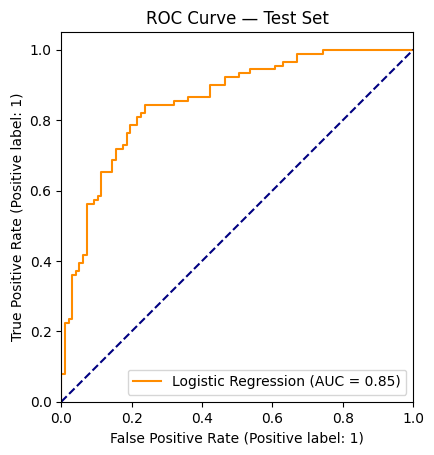

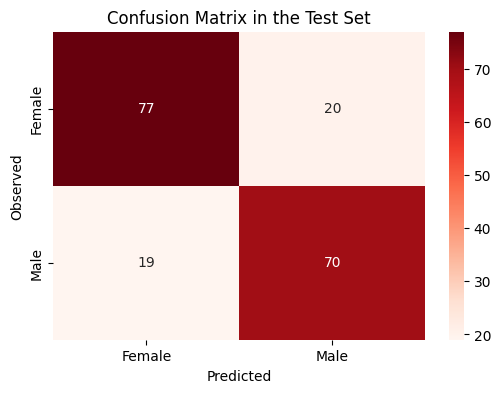

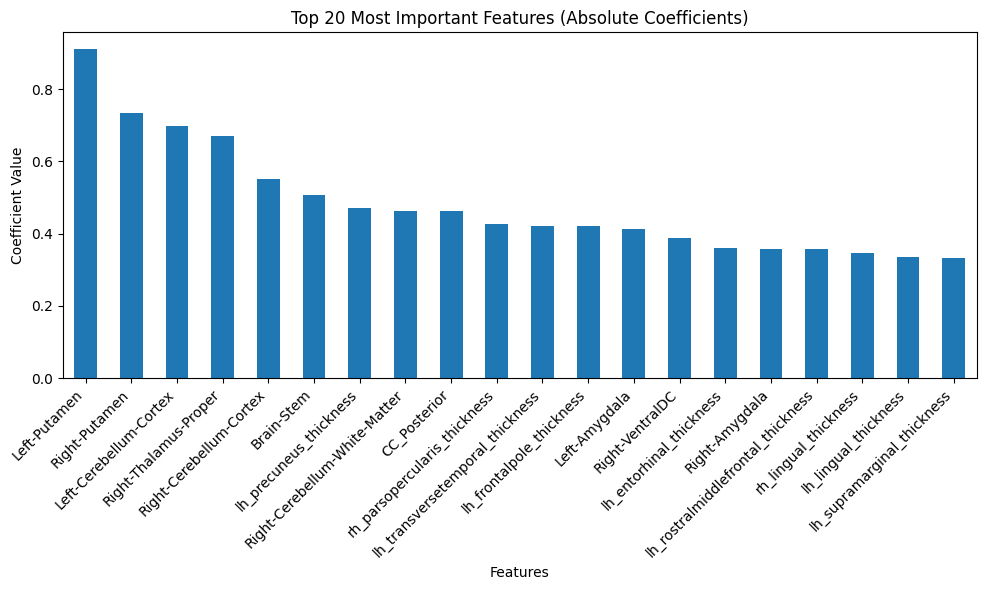

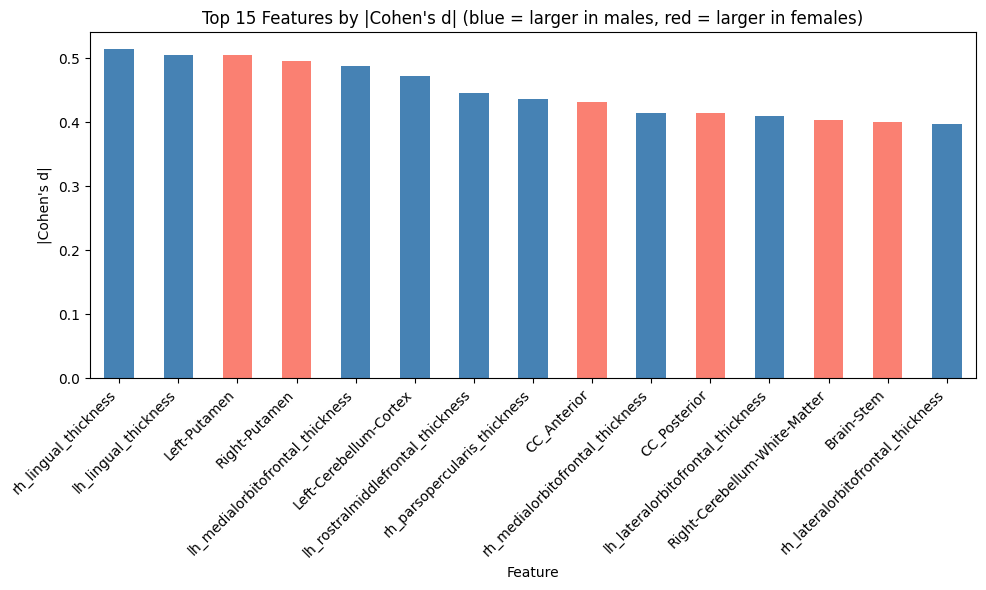

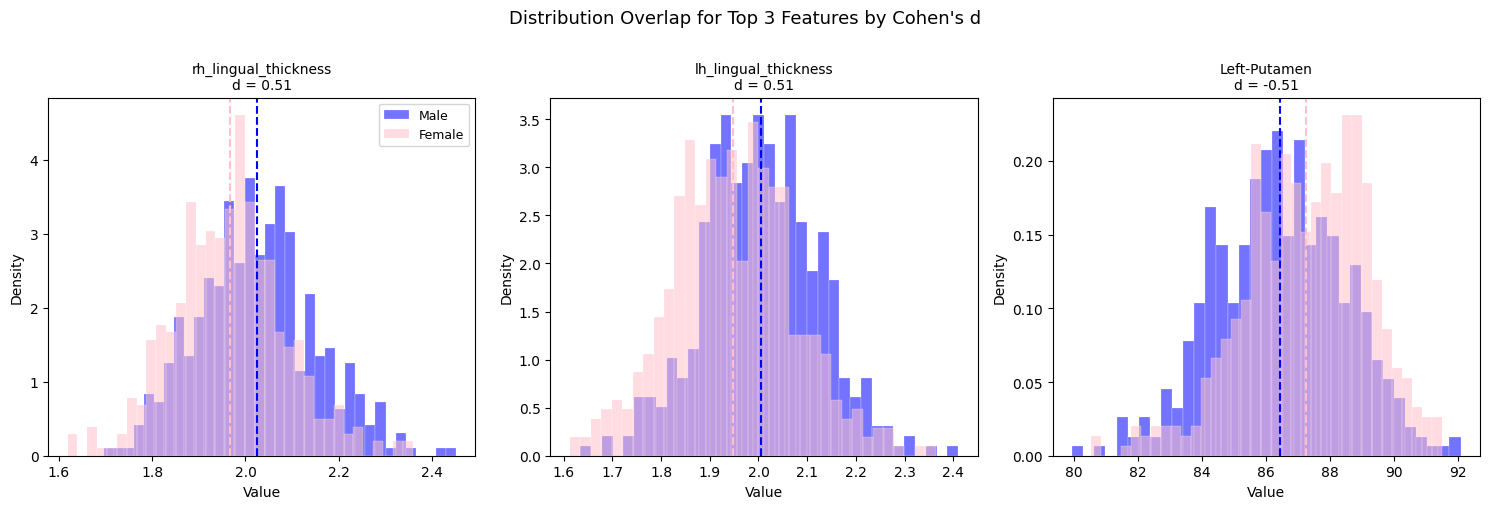

In [13]:
# Plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name='Logistic Regression',
    color='darkorange'
)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve — Test Set')

#cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title('Confusion Matrix in the Test Set')
plt.xlabel('Predicted')
plt.ylabel('Observed')

# Plot the 20 most important features based on the absolute coefficients of the logistic regression model
feature_importance = pd.Series(best_model.named_steps['clf'].coef_[0], index=selected_features)
plt.figure(figsize=(10, 6))
feature_importance.abs().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Top 20 Most Important Features (Absolute Coefficients)')
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
top3_features = effect_sizes.abs().sort_values(ascending=False).head(3).index.tolist()

# Bar chart of top 15 features by Cohen's d
plt.figure(figsize=(10, 6))
top_d = effect_sizes.abs().sort_values(ascending=False).head(15)
colors = ['steelblue' if effect_sizes[f] > 0 else 'salmon' for f in top_d.index]
top_d.plot(kind='bar', color=colors)
plt.title("Top 15 Features by |Cohen's d| (blue = larger in males, red = larger in females)")
plt.ylabel("|Cohen's d|")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_cohens_d.png', dpi=150, bbox_inches='tight')
plt.show()

# Use the FULL dataset for distribution plots (not just training) for richer visualisation
full_df = pd.DataFrame(X, columns=selected_features)
full_df['sex'] = ['Male' if s == 1 else 'Female' for s in y]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(top3_features):
    d_val = effect_sizes[feat]
    for sex_label, color in [('Male', 'blue'), ('Female', 'pink')]:
        subset = full_df[full_df['sex'] == sex_label][feat]
        axes[i].hist(
            subset, bins=35, alpha=0.55, color=color,
            label=sex_label, density=True, edgecolor='white', linewidth=0.3
        )
        axes[i].axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{feat}\nd = {d_val:.2f}', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('Distribution Overlap for Top 3 Features by Cohen\'s d', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_distribution_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Interpretation and Reflection (50%)

Interpretation (~400-500 words):
- What is your classification accuracy? Is this high or low, and compared to what?
- Which brain measures show the largest sex differences?
- How much overlap exists between groups? What proportion of variance is explained by sex?
- What do your results suggest about structural sex differences in the brain?

Reflection (~600-800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about neuroimaging analysis?

*Feel free to structure it with subheadings, bullet points using Markdown (e.g., **bold**, *italic*, `code`). You can look up the syntax for Markdown here: https://www.markdownguide.org/basic-syntax/.*

**Interpretation**
My logistic regression model achieved a test accurary of .79 and a ROC AUC of .85. An accuracy of 1 means all classifications were correct, so .79 is not amazing but pretty good for dealing with MRI data. AUC measures how well the model seperates males and females, with a chance level of .5.

The confusion matrx shows balanced performance across groups. The model correctly classified 77 females and 70 males, so similar error rates. This shows the model does not have a strong bias for one or the other. Misclassification still happens, with 19 and 20 for switched???? Still the overall accuary means the features chosen provide useful but not perfect informatoin fdor predicting sex.

The largest sex differences were observed in both cortical thickness and subcorital volumes. The strongest effect based on Cohen's d weere in the lingual cortex (both left and right hemisphere), putamen (left and right), and left hemisphere medial orbitofrontal regions. They all have effect sizes are .5, which is moderate (accoridng to the standard), highlights consistent group differences.

Despite these differences, there is substantial overlap between male and female distributions. Since the effect sizes aren't large it means there many individuals that have values the fall within the range of the other group,  shown by the distribution graphs of the top 3 features by cohen's d. This shows there is some individual  variance, if there was smaller overlap, the accurary and AUC would be closer to 1.

Overall, these findings suggest that structural sex differences in the brain are distributed across multiple regions rather than driven by a single feature, since the effect sizes are relatively similar. Both cortical thickness and subcortical volumes contribute to prediction, but their effects are moderate and overlapping. This supports the view that sex differences are meaningful at the group level but do not form clear, separable categories at the individual level.

**Reflection**


Sources:

[cohen's d](https://stackoverflow.com/questions/21532471/how-to-calculate-cohens-d-in-python?)

[chatGPT](https://chatgpt.com/c/69c65782-f844-8332-ab24-ef39822bc07d)

